# Patch optimization
[![Google Collab Book](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/optimization/planar/patch_placement.ipynb)


Fiber Patch Placement (FPP) is an additive composite manufacturing process, in which a robot assembles individual fiber patches to a structure with tailored fiber architecture. This allows for a lot of design freedom, but finding the optimal patch pattern is challenging. This notebook addresses the optimization problem of placing a certain amount of patches on a base laminate to maximize it's stiffness.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pygmsh
import torch
from matplotlib.patches import Rectangle
from scipy.stats import qmc
from torchfem import Planar
from torchfem.materials import OrthotropicElasticityPlaneStress
from tqdm import tqdm

torch.set_default_dtype(torch.float64)

## Material model
The material of each patch is an orthotropic plane-stress material.

The stiffness (represented by the full 2x2x2x2 stiffness tensor) of the laminate is then computed as 

$$
\mathbf{C}^\textrm{eff} = \frac{1}{N} \sum_1^N \mathbf{R}(\phi_i) \mathbf{R}(\phi_i) \mathbf{C} \mathbf{R}^\top(\phi_i) \mathbf{R}^\top(\phi_i)
$$
with rotation tensors $\mathbf{R}(\phi_i)$ for each ply orientation $\phi_i$.


In [2]:
def R(phi: torch.Tensor):
    return torch.stack(
        [
            torch.stack([torch.cos(phi), -torch.sin(phi)]),
            torch.stack([torch.sin(phi), torch.cos(phi)]),
        ]
    )

In [3]:
# Composite data from laminate fitting
E_xx = 136101.0
E_yy = 1442.0
G_xy = 8685.0
nu_xy = 0.954
material = OrthotropicElasticityPlaneStress(E_xx, E_yy, nu_xy, G_xy)

# Cross ply base layer
R90 = R(torch.tensor(np.pi / 2))
C0 = 0.5 * (
    material.C
    + torch.einsum(
        "...ijkl,...mi,...nj,...ok,...pl->...mnop", material.C, R90, R90, R90, R90
    )
)

## Base geometry
The test geometry is a symmetric quarter plate with an elliptical hole: 

![Sketch of the plate geometry](https://meyer-nils.github.io/torch-fem/images/plate_sketch.png)


Info    : Cannot bind existing OpenCASCADE surface 1 to second tag 2
Info    : Could not preserve tag of 2D object 2 (->1)
Info    : Cannot bind existing OpenCASCADE surface 1 to second tag 3
Info    : Could not preserve tag of 2D object 3 (->1)


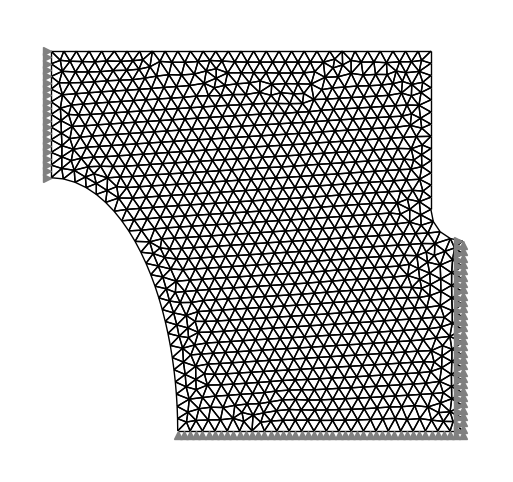

In [4]:
# Plate length
L = 120.0
# Plate width
W = 120.0
# Lash size
l = 5.0
# Lash fillet
r = 5.0
# Clamp size
c = 60.0
# Ellipse radii
R1 = 20.0
R2 = 40.0
# Base layer thickness
t0 = 0.3
# Patch thickness
t = 0.2
# Element size
s = 2.0
# Applied displacement
U = 0.1

# Build geometry and mesh
with pygmsh.occ.Geometry() as geom:
    geom.characteristic_length_max = s
    # Rectangle
    rectangle = geom.add_rectangle([0.0, 0.0, 0.0], a=L / 2, b=W / 2)
    # Lashes
    lashes = geom.add_rectangle([0.0, 0.0, 0.0], a=L / 2 + l, b=c / 2)
    # Fillet
    fillet_base = geom.add_point([(L / 2), (c / 2), 0.0], s)
    fillet_center = geom.add_point([(L / 2) + r, (c / 2) + r, 0.0], s)
    fillet_start = geom.add_point([(L / 2) + r, (c / 2), 0.0], s)
    fillet_end = geom.add_point([(L / 2), (c / 2) + r, 0.0], s)
    arc = geom.add_circle_arc(fillet_start, fillet_center, fillet_end)
    line1 = geom.add_line(fillet_base, fillet_start)
    line2 = geom.add_line(fillet_end, fillet_base)
    fillet_surface = geom.add_curve_loop([line1, arc, line2])
    fillet = geom.add_plane_surface(fillet_surface)
    # Remove points after creating the fillet surface
    geom.remove(fillet_center)
    # Union for base plate
    base = geom.boolean_union([rectangle, lashes, fillet])
    # Subtract hole
    hole = geom.add_ellipsoid([0, 0, 0.0], [R1, R2, 10.0])
    symm_model = geom.boolean_difference(base, [hole])[0]
    # Generate mesh
    m = geom.generate_mesh(order=2)

# Set up planar model
nodes = torch.from_numpy(m.points[:, :2])
elements = torch.from_numpy(m.cells_dict["triangle6"].astype(np.int64))
plate = Planar(nodes, elements, material)

# Overwrite material and thickness for base layer
plate.material.C[:] = C0
plate.thickness[:] = 8 * t0

# Compute element centers
centers = torch.mean(plate.nodes[plate.elements, :], dim=1)

# Compute element areas
areas = plate.integrate_field()

# Set constraints
left = plate.nodes[:, 0] == 0
plate.constraints[left, 0] = True
right = plate.nodes[:, 0] >= l + L / 2
plate.constraints[right, :] = True
bottom = plate.nodes[:, 1] <= 1e-10
plate.constraints[bottom, 1] = True
plate.displacements[right, 0] = U

# Plot geometry
plate.plot()

### Solving the base model

In [5]:
# Solve
u, f, sigma, epsilon, state = plate.solve()

### Postprocessing of base model

Force on right side: 		 2.37 kN.
Part stiffness: 		 23.69 kN/mm
Volume: 			 30019.66 mm³.
Strain energy: 			 118.45 J.


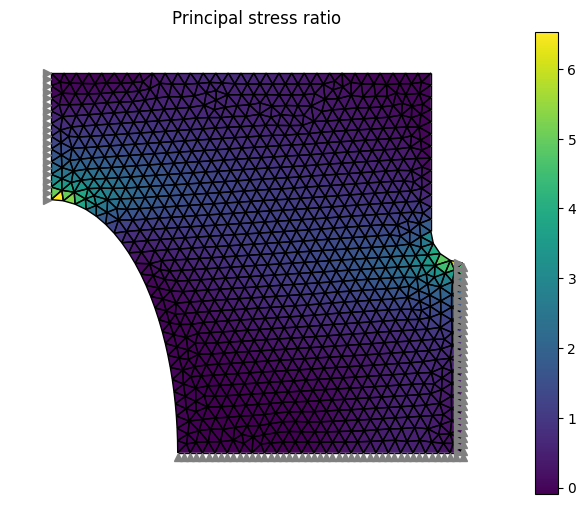

In [6]:
# Force in kN
F_base = f[right, 0].sum() / 1000
print(f"Force on right side: \t\t {F_base:.2f} kN.")

# Part stiffness
K_base = F_base / U
print(f"Part stiffness: \t\t {K_base:.2f} kN/mm")

# Volume (multiply by 4 since we only modeled a quarter of the plate)
V_base = 4 * torch.inner(plate.thickness, areas)
print(f"Volume: \t\t\t {V_base:.2f} mm³.")

# Strain energy
W_base = 0.5 * torch.inner(u.ravel(), f.ravel())
print(f"Strain energy: \t\t\t {W_base:.2f} J.")

# Stress concentration plot
A0 = (c / 2) * plate.thickness.mean()
s0 = f[right, 0].sum() / A0
principal_stress_base = torch.max(torch.linalg.eigvals(sigma).real, dim=-1).values / s0
plate.plot(
    element_property=principal_stress_base,
    cmap="viridis",
    colorbar=True,
    title="Principal stress ratio",
)

## Patch class

In [7]:
class Patch:
    def __init__(self, length, width, position, angle):
        self.length = length
        self.width = width
        self.position = torch.as_tensor(position)
        self.angle = torch.as_tensor(angle)

    def get_vertices(self, mirror=None):
        # Position and angle
        x, y = self.position
        ca = torch.cos(self.angle)
        sa = torch.sin(self.angle)

        # Calculate half-length and half-width
        l2 = self.length / 2
        w2 = self.width / 2

        # Calculate the coordinates of the four corners
        vertices = torch.stack(
            [
                torch.stack([x - l2 * ca + w2 * sa, y - l2 * sa - w2 * ca]),
                torch.stack([x + l2 * ca + w2 * sa, y + l2 * sa - w2 * ca]),
                torch.stack([x + l2 * ca - w2 * sa, y + l2 * sa + w2 * ca]),
            ]
        )
        if mirror is not None:
            vertices[:, mirror] = -vertices[:, mirror]
        return vertices

    def C(self, mirror=None):
        if mirror is None:
            Rphi = R(self.angle)
        elif mirror == 1:
            Rphi = R(-self.angle)
        elif mirror == 0:
            Rphi = R(np.pi - self.angle)
        return torch.einsum(
            "...ijkl,...mi,...nj,...ok,...pl->...mnop",
            material.C,
            Rphi,
            Rphi,
            Rphi,
            Rphi,
        )

    @torch.no_grad()
    def get_visualization(
        self,
        mirror=None,
        color=np.array([42.0 / 255.0, 99.0 / 255.0, 96 / 255.0]),
        alpha=0.9,
    ):
        # Position and angle
        x, y = self.position
        if mirror is None:
            angle = self.angle
        elif mirror == 0:
            y = -y
            angle = -self.angle
        elif mirror == 1:
            x = -x
            angle = np.pi - self.angle
        elif mirror == 2:
            x = -x
            y = -y
            angle = np.pi + self.angle

        # Calculate half-length and half-width
        l2 = self.length / 2
        w2 = self.width / 2

        # Calculate one corner
        ca = torch.cos(angle)
        sa = torch.sin(angle)
        x1 = x - l2 * ca + w2 * sa
        y1 = y - l2 * sa - w2 * ca
        return Rectangle(
            (x1, y1),
            self.length,
            self.width,
            angle=torch.rad2deg(angle).float(),
            facecolor=color,
            alpha=alpha,
            edgecolor="black",
        )

## Weight computation 

Project points on edge $AB$ and $AC$. The projections are distances of each point to one corner of an rectangle in the element orientation. We can use it to define a patch coordinate system $\xi$-$\eta$ at the center of each patch. In this coordinates, we can define weights as

$$
w = e^{-\epsilon^2 (\hat{\xi}^2 + \hat{\eta}^2)}
$$
with 

$$
\hat{\xi} = \max{(\lvert \xi \rvert-L/2 + \frac{\sqrt{\ln{2}}}{\epsilon},0)} \\
\hat{\eta} = \max{(\lvert \eta \rvert-W/2 + \frac{\sqrt{\ln{2}}}{\epsilon},0)}
$$

where the maximum operator is used to set all values of $\hat{\xi}$ and $\hat{\eta}$ in a patch to 0, hence causing weights in the patch set to 1, the weights of the edge to 0.5 and approaching 0 far away from the patch.

In [8]:
def compute_weight(corners, eps=0.5):
    # Projection to AB
    ab = corners[:, 1] - corners[:, 0]
    am = centers[None, :, :] - corners[:, None, 0]
    amab = torch.einsum("...ij,...j->...i", am, ab)
    abab = torch.einsum("...i,...i->...", ab, ab)
    L = torch.sqrt(abab)[:, None]

    # Projection to BC
    bc = corners[:, 2] - corners[:, 1]
    bm = centers[None, :, :] - corners[:, None, 1]
    bmbc = torch.einsum("...ij,...j->...i", bm, bc)
    bcbc = torch.einsum("...i,...i->...", bc, bc)
    W = torch.sqrt(bcbc)[:, None]

    # Compute the weight
    zeros = torch.zeros(amab.shape)
    xi = amab / L - L / 2
    eta = bmbc / W - W / 2
    offset = 1 / eps * np.sqrt(np.log(2.0))
    xi_hat = torch.max(torch.abs(xi) - L / 2 + offset, zeros)
    eta_hat = torch.max(torch.abs(eta) - W / 2 + offset, zeros)

    weight = torch.exp(-(eps**2) * (xi_hat**2 + eta_hat**2))
    return weight

### Test patches 

We create three test patches to illustrate mirroring and stiffness projection.

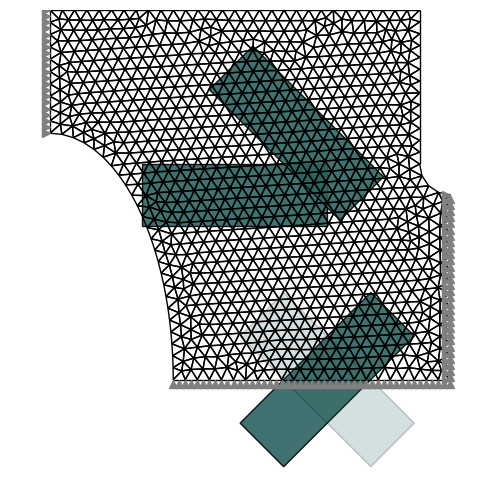

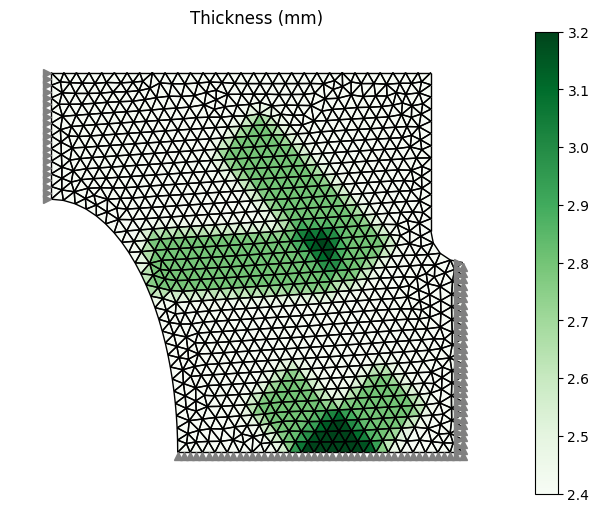

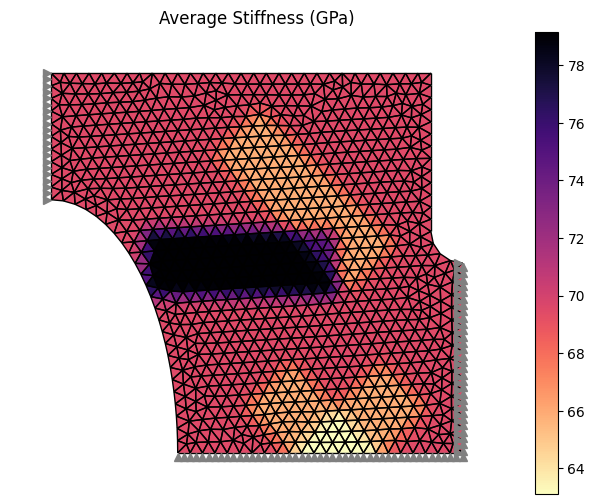

In [9]:
test_patch_1 = Patch(30.0, 10.0, torch.tensor([30.0, 30.0]), 0.0)
test_patch_2 = Patch(30.0, 10.0, torch.tensor([40.0, 40.0]), -np.pi / 4)
test_patch_3 = Patch(30.0, 10.0, torch.tensor([45.0, 0.0]), np.pi / 4)

# Plot test patch
plate.plot()
ax = plt.gca()
ax.add_patch(test_patch_1.get_visualization())
ax.add_patch(test_patch_2.get_visualization())
ax.add_patch(test_patch_3.get_visualization())
ax.add_patch(test_patch_3.get_visualization(mirror=0, alpha=0.2))
plt.ylim(-15, 60)
plt.show()

vertices = torch.stack(
    [
        test_patch_1.get_vertices(),
        test_patch_2.get_vertices(),
        test_patch_3.get_vertices(),
        test_patch_3.get_vertices(mirror=1),
    ]
)
weights = compute_weight(vertices)
thickness = 8 * t0 + 2 * t * weights.sum(dim=0)
plate.plot(
    element_property=thickness,
    colorbar=True,
    cmap="Greens",
    title="Thickness (mm)",
)


# Plot stiffness
Cs = torch.stack(
    [
        test_patch_1.C(),
        test_patch_2.C(),
        test_patch_3.C(),
        test_patch_3.C(mirror=1),
    ]
)
C_eff = (
    2 * t * torch.einsum("ij,iklmn->jklmn", weights, Cs) + 8 * t0 * C0[None, :, :, :, :]
) / thickness[:, None, None, None, None]
plate.plot(
    element_property=C_eff[:, 0, 0, 0, 0] / 1000.0,
    colorbar=True,
    cmap="magma_r",
    title="Average Stiffness (GPa)",
)

## Optimization of patch placement with gradient decent 

### Random initial samples

An initial patch configuration for optimization is sampled. Please note that this problem is not convex, so the gradient decent may end up at different solutions for different random starting points. It is highly recommended to perform multiple optimization runs and pick the best one (multi-start gradient decent). Usually, this still clearly outperforms any non-differentiable approach like genetic algorithms or other global search strategies.

In [10]:
# Number of patches to create on quarter plate. The
N = 2

# Patch dimensions
length = 30.0
width = 10.0

# Random samples
samples = qmc.LatinHypercube(d=2).random(N)
samples[:, 0] = samples[:, 0] * L / 2
samples[:, 1] = samples[:, 1] * W / 2
orientations = np.pi * torch.rand(N)
positions = torch.tensor(samples)
positions.requires_grad = True
orientations.requires_grad = True

# Create patches
patches = [Patch(length, width, p, o) for p, o in zip(positions, orientations)]

### Objective function and minimization

Here we formulate a function that evaluates relative strain energy and volume for a given set of patch positions `pos` and patch orientations `ori`. It creates the patches and computes the resulting thickness 

$$
\tilde{t} = 8 t_0 + 2 t \sum_{p=1}^{3N}w_p 
$$

and stiffness 

$$
\tilde{\mathbf{C}} = \frac{1}{\tilde{t}} \left(8t_0 \mathbf{C}^0 +  2 t \sum_{p=1}^{3N} w_p \mathbf{C}_p\right).
$$

Subsequently, we solve the optimization problem 

$$
\max_{\{x_p, y_p, \theta_p\}_{p=1}^{N}} \frac{W}{W^0} + \lambda \frac{V}{V^0},
$$

with a gradient decent to find a tuple of optimal patch parameters $\{x_p, y_p, \theta_p\}_{p=1}^{N}$.

In [11]:
def strain_energy(pos, ori):
    patches = [Patch(length, width, p, o) for p, o in zip(pos, ori)]
    vertices = torch.stack(
        [patch.get_vertices() for patch in patches]
        + [patch.get_vertices(mirror=0) for patch in patches]
        + [patch.get_vertices(mirror=1) for patch in patches]
    )
    weights = compute_weight(vertices)
    Cs = torch.stack(
        [patch.C() for patch in patches]
        + [patch.C(mirror=0) for patch in patches]
        + [patch.C(mirror=1) for patch in patches]
    )
    plate.thickness = 8 * t0 + 2 * t * weights.sum(dim=0)
    plate.material.C = (
        2 * t * torch.einsum("ij,iklmn->jklmn", weights, Cs)
        + 8 * t0 * C0[None, :, :, :, :]
    ) / plate.thickness[:, None, None, None, None]
    u, f, _, _, _ = plate.solve(method="spsolve", differentiable_parameters=(pos, ori))
    return (
        0.5 * torch.inner(u.ravel(), f.ravel()) / W_base,
        4 * torch.inner(plate.thickness, areas) / V_base,
    )

In [12]:
# Optimize with Adam
optimizer = torch.optim.Adam([positions, orientations], lr=0.1)

c_hist = []
w_hist = []
pos_hist = []
ori_hist = []
LBD = 100.0
iterations = 1000
for i in tqdm(range(iterations)):
    # Evaluate
    optimizer.zero_grad()
    c, vol = strain_energy(positions, orientations)
    loss = -(c + W * vol * i / iterations)
    # Track history
    with torch.no_grad():
        c_hist.append(c.item())
        w_hist.append(vol.item())
        pos_hist.append(positions.clone())
        ori_hist.append(orientations.clone())
    # Optimize
    loss.backward()
    optimizer.step()

100%|██████████| 1000/1000 [01:57<00:00,  8.53it/s]


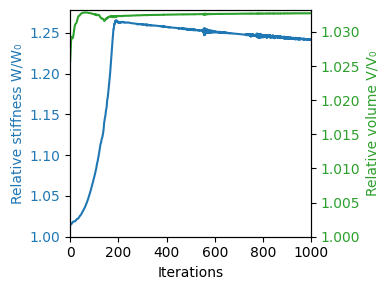

In [13]:
fig, ax1 = plt.subplots(figsize=(4, 3))

# Left y-axis (Stiffness)
ax1.plot(c_hist, color="tab:blue", label="Strain Energy")
ax1.set_xlabel("Iterations")
ax1.set_xlim([0, iterations])
ax1.set_ylim(bottom=1.0)
ax1.set_ylabel("Relative stiffness W/W₀", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right y-axis (Regularization)
ax2 = ax1.twinx()
ax2.plot(w_hist, color="tab:green", label="Regularization")
ax2.set_ylabel("Relative volume V/V₀", color="tab:green")
ax2.set_ylim(bottom=1.0)
ax2.tick_params(axis="y", labelcolor="tab:green")
ax2.ticklabel_format(useOffset=False)

# Show plot
plt.tight_layout()
plt.show()

### Optimization results

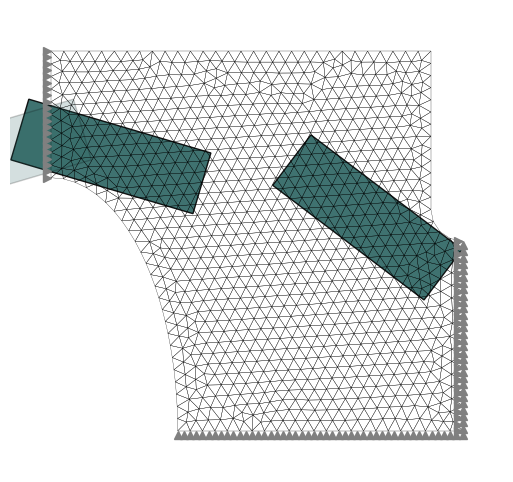

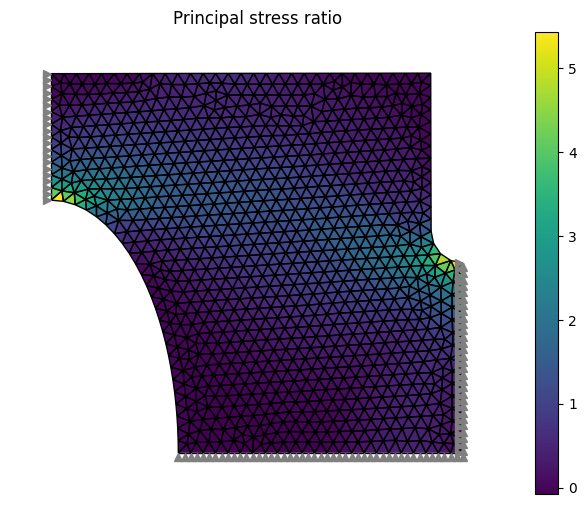

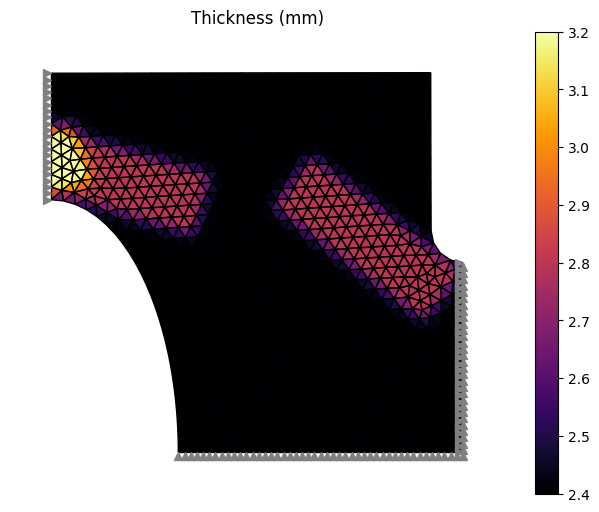

In [14]:
u, f, sigma, _, _ = plate.solve()

# Plot patches on quarter plate
with torch.no_grad():
    plate.plot(linewidth=0.2)
    ax = plt.gca()
    for patch in patches:
        ax.add_patch(patch.get_visualization())
        # Mirrored "ghost patches" for visualization
        ax.add_patch(patch.get_visualization(mirror=0, alpha=0.2))
        ax.add_patch(patch.get_visualization(mirror=1, alpha=0.2))
        ax.add_patch(patch.get_visualization(mirror=2, alpha=0.2))

# Stress concentration plot
s0 = f[right, 0].sum() / A0
principal_stress_opti = torch.max(torch.linalg.eigvals(sigma).real, dim=-1).values / s0
plate.plot(
    u=u,
    element_property=principal_stress_opti,
    cmap="viridis",
    colorbar=True,
    title="Principal stress ratio",
)

# Thickness plot
plate.plot(
    u=u,
    element_property=plate.thickness,
    cmap="inferno",
    colorbar=True,
    title="Thickness (mm)",
)

## Postprocessing of optimized plate 

The patches should add a lot of stiffness increase for a relatively small increase in weight. Keep in mind: the problem is not convex and multiple restart with different starting positions are recommended.


In [15]:
# Force
F_optimal = f[right, 0].sum() / 1000.0
print(f"Force on right side:\t\t {F_optimal:.2f} kN.")

# Stiffness
print(f"Part stiffness: \t\t {F_optimal / U:.2f} kN/mm.")

# Volume
V_optimal = 4 * torch.inner(plate.thickness, areas)
print(f"Volume: \t\t\t {V_optimal:.2f} mm³.")

# Strain energy
W_optimal = 0.5 * torch.inner(u.ravel(), f.ravel())
print(f"Strain energy: \t\t\t {W_optimal:.2f} J.")

Force on right side:		 2.94 kN.
Part stiffness: 		 29.41 kN/mm.
Volume: 			 31002.08 mm³.
Strain energy: 			 147.03 J.


In [16]:
# Stiffness increase
print(f"Stiffness increase: \t\t {(100*(F_optimal / F_base-1)):.2f}%.")

# Volume increase
print(f"Volume increase: \t\t {(100*(V_optimal / V_base)-100):.2f}%.")

Stiffness increase: 		 24.12%.
Volume increase: 		 3.27%.
